In [ ]:
import pandas as pd

# Path to data frame with WSIs
df_path = "D:\DATA\with_snomed_category.csv"
df_all = pd.read_csv(df_path)
print(df_all.columns)

# Path to cache file
cache_file = "cache_all_slides.pkl"

# Path to zarr
local_dir = r"D:\NOTEBOOKS\Christine\all_slides\zarr"

In [ ]:
from helper_functions import strings2lists

list_str_cols = ['snomed_code', 'M', 'T', 'snomed_text', 'T_text', 'M_text', 'undersoeger_anonymous', 'T_category', 'M_category']

for col in list_str_cols: 
    df_all[col] = df_all[col].apply(strings2lists)

In [ ]:
from helper_functions import subset_df, subset_df_list

df_HE = subset_df(df_all, "stain", "HE")
df_HE = subset_df(df_HE, "mattype tekst", "Hist. store")
df_HE = subset_df_list(df_HE, "T_category", "Placenta, Fetal Membranes, and Fetus")

In [ ]:
all_filenames = df_HE["filename"].tolist()
unique_wsi = set(all_filenames)

print("Number of unique wsi filenames: ",  len(unique_wsi))
print("Number of wsi filenames: ", len(all_filenames))

In [ ]:
feature_result = r"D:\NOTEBOOKS\Christine\all_slides\combined_feature_summary.csv"
df_feature_result = pd.read_csv(feature_result)
df_feature = df_feature_result[df_feature_result['status'] == "feature extraction complete"]["wsi_path"].astype(str)
with_features = set(df_feature)
print("WSIs with features detected: ", len(with_features))
all_filenames = list(with_features)

In [ ]:
from aicsimageio import AICSImage
import zarr
from skimage.transform import downscale_local_mean

def open_czi_as_wsi(path, zarr_path):
    img = AICSImage(path)
    data = img.get_image_data("CYX")
    store = zarr.open(zarr_path, mode="w")
    levels = [data]

    for _ in range(4):
        levels.append(downscale_local_mean(levels[-1], (1, 2, 2)))

    for i, lvl in enumerate(levels):
        store.create_dataset(str(i), data=lvl, chunks=(1, 512, 512))

    return zarr.open(zarr_path, mode="r")

In [1]:
# Visualize Single Slide
import os
from aicsimageio import AICSImage
import numpy as np
    
#path = all_filenames[0]
path = r"/Users/rct905/Documents/MaxPlanck_HE_lung_skin/270426_9615_20_skin3a.czi"
local_dir = r"/Users/rct905/Documents/MaxPlanck_HE_lung_skin/zarr"

zarr_path = os.path.join(local_dir, os.path.basename(path).replace(".czi", ".zarr"))
# zarr_path = os.path.join(local_dir, os.path.basename(path).replace(".mrxs", ".zarr"))
#wsi = open_wsi(path, zarr_path)

#wsi = open_wsi(path, zarr_path, reader="bioformats")
#wsi


In [ ]:
from aicsimageio import AICSImage
import numpy as np

img = AICSImage(path, reconstruct_mosaic=False)
print(img.dims)

# robust extraction
try:
    data = img.get_image_data("YX S")  # RGB case
    data = np.moveaxis(data, -1, 0)   # → (C, Y, X)
except:
    data = img.get_image_data("CYX")

print(data.shape)

<Dimensions [M: 1540, T: 1, C: 1, Z: 1, Y: 2464, X: 2056, S: 3]>


In [ ]:
import zarr
from skimage.transform import downscale_local_mean

store = zarr.open(zarr_path, mode="w")

levels = [data]

for i in range(1, 6):
    down = downscale_local_mean(levels[-1], (1, 2, 2))
    levels.append(down.astype(data.dtype))

for i, lvl in enumerate(levels):
    store.create_dataset(
        str(i),
        data=lvl,
        chunks=(1, 512, 512)
    )

In [ ]:
import lazyslide as zs
zs.tl.spatial_domain(
    wsi,
    feature_key="features_conch",  
    tile_key="tiles_224",                
    resolution=0.2,                    
    key_added="domain"                  
)
zs.pl.tiles(wsi, tissue_key= "tissue_default", tile_key="tiles_224", color="domain", alpha=0.5)

In [ ]:
# Concatenate tiles belonging to the same domain into shapes
zs.tl.tile_shaper(
    wsi,
    groupby='domain',       
    tile_key='tiles_224',    
    key_added='domain_shapes'
)

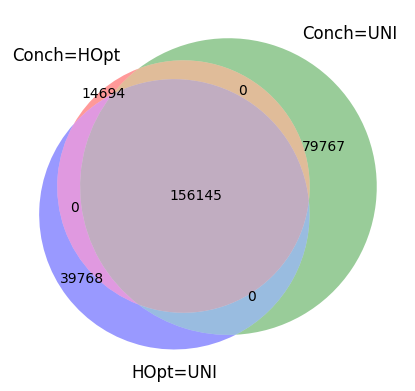

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn3

# -----------------------------
# 1. Load the sets
# -----------------------------
set_conch_hopt = set(pd.read_csv("/Users/rct905/Documents/conch_hopt.csv")["tile_id"])
set_conch_uni = set(pd.read_csv("/Users/rct905/Documents/conch_uni.csv")["tile_id"])
set_hopt_uni = set(pd.read_csv("/Users/rct905/Documents/hopt_uni.csv")["tile_id"])

# -----------------------------
# 2. Plot Venn diagram
# -----------------------------
venn3(

    [set_conch_hopt, set_conch_uni, set_hopt_uni],
    set_labels=("Conch=HOpt", "Conch=UNI", "HOpt=UNI")
)

plt.show()